# Data Workshop 2 :: Statistical Analysis


## Data Sets
- [Male/Female Heights](https://www.openintro.org/data/index.php?data=speed_gender_height)
  - Our goal will be to claim what the average height is in this sample
  - Our goal will also be to determine if the height of males on average is greater than the females
- [FAMuSS](https://www.openintro.org/data/index.php?data=famuss)
  - We will evaluate the data in the non-dominate arm (ndrm.ch) before and after training, given a particular genotype.



## Learning objectives
- Hypothesis Testing
  - *p*-test
  - *t*-test
  - *t*-test (comparing two means)
  - ANOVA

## Libraries

In [50]:
#Libraries
import pandas as pd
import plotly.express as px
import scipy.stats as stats #Gives us stat functions
import plotly.graph_objects as go

## Don't forget!

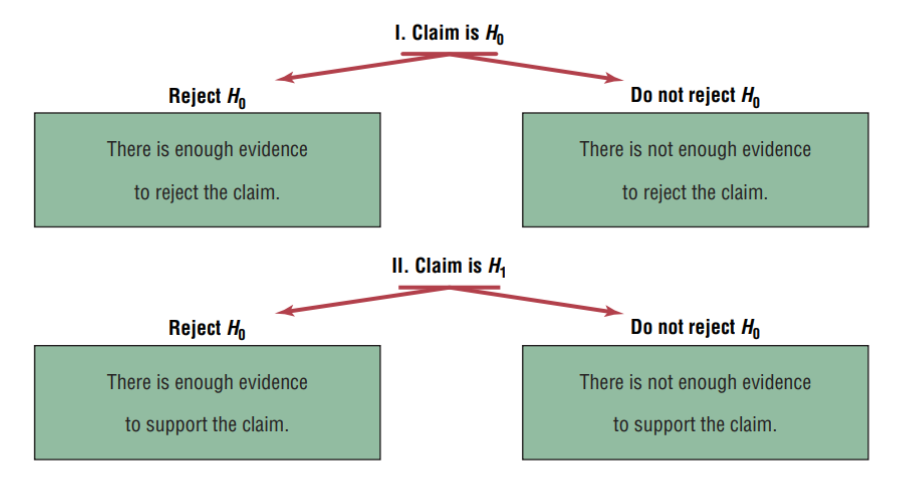

In [51]:
#Loading in data
df_FAMuSS = pd.read_csv('/content/famuss.csv')
df_FAMuSS

,ndrm.ch,drm.ch,sex,age,race,height,weight,actn3.r577x,bmi
0,40.0,40.0,Female,27,Caucasian,65.0,199.0,CC,33.112
1,25.0,0.0,Male,36,Caucasian,71.7,189.0,CT,25.845
2,40.0,0.0,Female,24,Caucasian,65.0,134.0,CT,22.296
3,125.0,0.0,Female,40,Caucasian,68.0,171.0,CT,25.998
4,40.0,20.0,Female,32,Caucasian,61.0,118.0,CC,22.293
...,...,...,...,...,...,...,...,...,...
590,62.5,28.6,Male,24,Asian,71.5,163.0,CC,22.415
591,87.5,12.5,Female,22,Caucasian,65.5,136.0,CT,22.285
592,100.0,12.5,Female,21,Asian,59.0,99.5,CT,20.094
593,43.8,14.3,Female,31,Caucasian,64.0,134.0,CT,22.999


In [52]:
#Load in Data
df_height = pd.read_csv('/content/speed_gender_height.csv')
df_height

,speed,gender,height
0,85.0,female,69.0
1,40.0,male,71.0
2,87.0,female,64.0
3,110.0,female,60.0
4,110.0,male,70.0
...,...,...,...
1320,97.0,female,63.0
1321,100.0,female,66.0
1322,90.0,female,63.0
1323,90.0,male,69.0


## [$t$-test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html) (Click me for documentation!)



Given the data on UCLA drivers, we want to consider what the average height might be. Let our claimed height to be $C=69$ inches (a little over 5'7).

$H_0 : \mu_1 = C$ **(Claim)**

$H_1 : \mu_1 \neq C$

Suppose $\alpha = .05$, what can we conclude if our hypothesis is $H_0$.

In [56]:
#Organize Data
group_gender =df_height.groupby("gender").groups

male = df_height["height"].loc[group_gender["male"]].dropna()
female= df_height["height"].loc[group_gender["female"]].dropna()
male

,height
1,71.0
4,70.0
9,69.0
11,72.0
12,70.0
...,...
1304,60.0
1309,69.0
1312,71.0
1318,68.0


In [57]:
stats.ttest_1samp(male, popmean=69)
#First parameter is the data
#Popmean is the expected value (claimed value)


TtestResult(statistic=np.float64(3.952240834528328), pvalue=np.float64(9.01476379254167e-05), df=np.int64(441))

In [ ]:
fig_male_height = go.Figure()
fig_male_height.add_trace(go.Histogram(x=male, nbinsx=20))


Conclusion :

## [$t$-test*](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) (comparing two means)

Given the data on UCLA drivers, we want to consider what the difference in average height might be. Let our claimed height to be $\mu_1 \neq \mu_2$.

(Claim)

$H_0 : \mu_1 = \mu_2$

$H_1 : \mu_1 \neq \mu_2$ **(Claim)**

Suppose $\alpha = .05$, what can we conclude if our hypothesis is $H_0$?

In [58]:
stats.ttest_ind(male,female, equal_var=True)
# First / Second Parameter -> two samples you are testing
# equal_var -> is asking should we assume that the variance to be equal?

TtestResult(statistic=np.float64(28.647342941683508), pvalue=np.float64(1.0205453181247639e-140), df=np.float64(1318.0))

Conclusion :

## ANOVA
Here will use the data from FAMuSS. We create the categories based on genotype with their corresponding strength change in the non-dominate arm.

Recall for the ANOVA test has the corresponding null and alternative hypothesis.

$H_0 : \mu_1 = \mu_2 = \cdots = \mu_k$

$H_1 : \mu_1 \neq \mu_2 \neq \cdots \neq \mu_k$ (at least one is different)

Suppose $\alpha = .05$, what can we conclude if our claim is that our means are different?

In [ ]:
fig_ndrm = px.box(df_FAMuSS, x="actn3.r577x", y="ndrm.ch")
fig_ndrm

In [59]:
#ndrm non-dominate arm
#drm domiante arm

# Conider the nrdm
# CC | CT | TT

groups =df_FAMuSS.groupby("actn3.r577x").groups

CC = df_FAMuSS["ndrm.ch"].loc[groups["CC"]]
CT= df_FAMuSS["ndrm.ch"].loc[groups["CT"]]
TT = df_FAMuSS["ndrm.ch"].loc[groups["TT"]]

stats.f_oneway(CC,CT,TT)

# After we want to
# Post Hoc test, pair, 3 t-test... only one of them is .016


F_onewayResult(statistic=np.float64(3.2307803478895685), pvalue=np.float64(0.04022462350595486))

## Lab ::

In post-hoc (after conducting the hypothesis test/ experiment), we now may want to consider what if we do a $t$-test pair wise. Use the $t$-test to determine which group(s) are different/greater from the rest? Or are they all different ?